In [20]:
# ==================
# IMPORTS
# ==================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

In [21]:
# ==================
# CONFIGURATION
# ==================
warnings.filterwarnings("ignore")

ACCENT_PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff', '#f85149', '#56d4dd']

plt.rcParams.update({
    'figure.facecolor': '#0d1117',

    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#e6edf3',
    'axes.prop_cycle': plt.cycler(color=ACCENT_PALETTE),

    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',

    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#cccccc',
    'grid.linestyle': "--",
    'grid.alpha': 0.75,

    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',

    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

sns.set_palette(ACCENT_PALETTE)

In [22]:
# ==================
# DATA PREPARATION
# ==================
def load_data(path: str) -> pd.DataFrame:
    data_path = Path(path)
    if not data_path.exists():
        raise FileNotFoundError(f"{data_path} does not exist")

    return pd.read_csv(path)

In [23]:
metadata = load_data("../data/raw_data/raw_country_metadata.csv")
year_indicators = load_data("../data/raw_data/raw_country_year_indicators.csv")
stress_score = load_data("../data/raw_data/raw_economic_stress_score.csv")

In [24]:
# ==================
# DATA ANALYSIS
# ==================
print(f"Metadata: {metadata.shape}")
print(f"Year indicators: {year_indicators.shape}")
print(f"Stress score: {stress_score.shape}")

Metadata: (217, 7)
Year indicators: (14322, 18)
Stress score: (14322, 12)


In [25]:
print(f"Metadata missing values: {metadata.isna().sum()}")
print("")
print(f"Year indicators missing values: {year_indicators.isna().sum()}")
print("")
print(f"Stress score missing values: {stress_score.isna().sum()}")

Metadata missing values: country_code    0
country_name    0
iso3            0
region          0
income_group    0
latitude        6
longitude       6
dtype: int64

Year indicators missing values: country_code                          0
country_name                          0
iso3                                  0
region                                0
income_group                          0
year                                  0
gdp_growth                         3108
inflation                          5351
unemployment                       7791
gdp_per_capita                     2753
population                          247
food_production_index              3311
cereal_yield                       3992
cereal_production_tonnes           3942
agricultural_land_pct              2262
dietary_energy_supply_adequacy    10491
economic_stress_score              1560
data_completeness_score               0
dtype: int64

Stress score missing values: country_code                      0
coun

In [26]:
# ==================
# UTILS
# ==================
def make_fully_missing_barplot(data: pd.DataFrame):
    missing_counts = data.isna().sum()

    sns.barplot(x=missing_counts.index, y=missing_counts.values)
    plt.xticks(rotation=30, ha="right")
    plt.title(f"Missing values count")
    plt.xlabel("DataFrame Columns")
    plt.ylabel("NaN Count")

    plt.tight_layout()
    plt.show()


def make_fully_boxplot(data: pd.DataFrame):
    numeric_cols = data.select_dtypes(include="number").columns
    n_cols = 3
    n_rows = -(-len(numeric_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        sns.boxplot(y=data[col], ax=axes[i])
        axes[i].set_title(col)

    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def fill_missing(data: pd.DataFrame, target: str, feature: str):
    data[target] = data.groupby(feature)[target].transform(
        lambda x: x.fillna(x.median())
    )
    return data


def drop_unfillable(data: pd.DataFrame, target: str):
    before = len(data)
    data = data[data[target].notna()]

    dropped = before - len(data)
    print(f"{target}: dropped {dropped} rows")

    return data


def clip_outliers(data: pd.DataFrame, target: str, upper_quantile: float=0.99, lower_quantile: float=0.01):
    upper = data[target].quantile(upper_quantile)
    lower = data[target].quantile(lower_quantile)
    data[target] = data[target].clip(lower=lower, upper=upper)
    return data

<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  217 non-null    str    
 1   country_name  217 non-null    str    
 2   iso3          217 non-null    str    
 3   region        217 non-null    str    
 4   income_group  217 non-null    str    
 5   latitude      211 non-null    float64
 6   longitude     211 non-null    float64
dtypes: float64(2), str(5)
memory usage: 12.0 KB


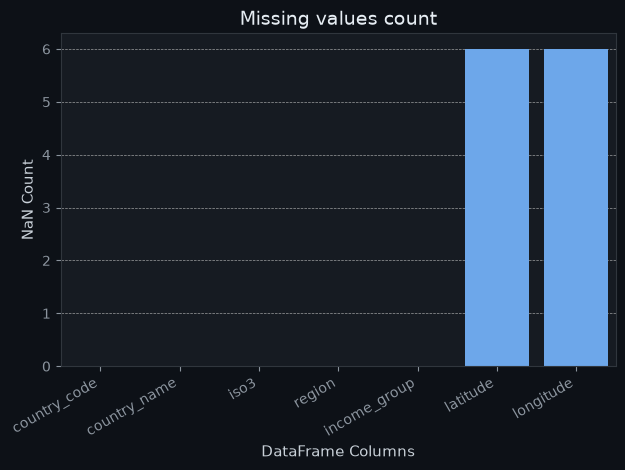

country_code    0
country_name    0
iso3            0
region          0
income_group    0
latitude        0
longitude       0
dtype: int64
0


In [27]:
# ==================
# NULLS & DUPLICATES METADATA
# ==================
metadata.info()
make_fully_missing_barplot(data=metadata)

metadata["latitude"] = metadata["latitude"].fillna(metadata["latitude"].median())
metadata["longitude"] = metadata["longitude"].fillna(metadata["longitude"].median())

print(metadata.isna().sum())
print(metadata.duplicated().sum())

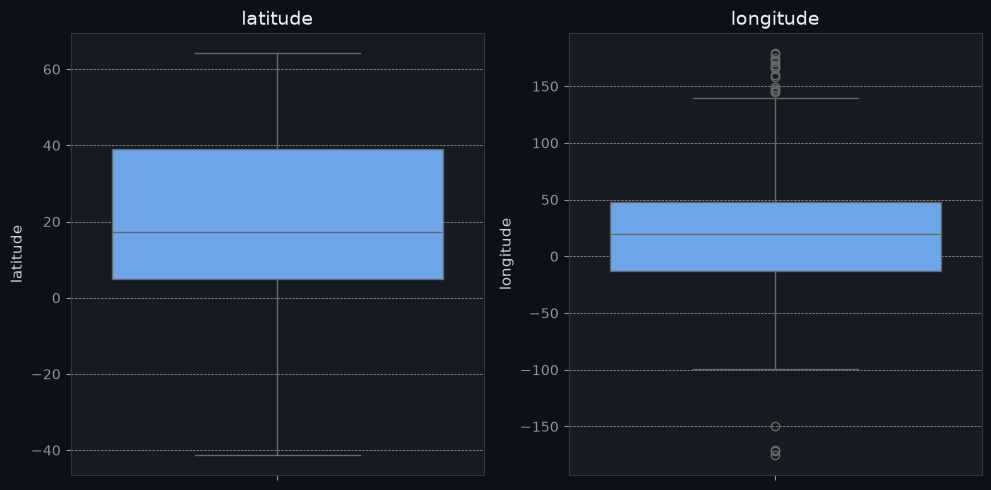

In [28]:
# ==================
# ANOMALIES METADATA
# ==================
make_fully_boxplot(metadata)

<class 'pandas.DataFrame'>
RangeIndex: 14322 entries, 0 to 14321
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country_code                    14322 non-null  str    
 1   country_name                    14322 non-null  str    
 2   iso3                            14322 non-null  str    
 3   region                          14322 non-null  str    
 4   income_group                    14322 non-null  str    
 5   year                            14322 non-null  int64  
 6   gdp_growth                      11214 non-null  float64
 7   inflation                       8971 non-null   float64
 8   unemployment                    6531 non-null   float64
 9   gdp_per_capita                  11569 non-null  float64
 10  population                      14075 non-null  float64
 11  food_production_index           11011 non-null  float64
 12  cereal_yield                    10330 non-n

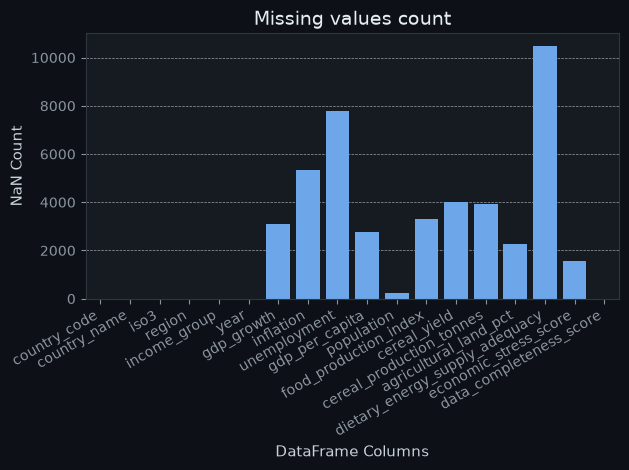

Shape after droping missing values: (12762, 18)


In [29]:
# ==================
# NULLS & DUPLICATES YEAR INDICATORS
# ==================
year_indicators.info()
make_fully_missing_barplot(data=year_indicators)

year_indicators = year_indicators[year_indicators["economic_stress_score"].notna()]
print(f"Shape after droping missing values: {year_indicators.shape}")

gdp_growth: dropped 297 rows
gdp_growth: NaN left = 0

inflation: dropped 0 rows
inflation: NaN left = 0

unemployment: dropped 5279 rows
unemployment: NaN left = 0

gdp_per_capita: dropped 0 rows
gdp_per_capita: NaN left = 0

population: dropped 0 rows
population: NaN left = 0

food_production_index: dropped 418 rows
food_production_index: NaN left = 0

cereal_yield: dropped 0 rows
cereal_yield: NaN left = 0

cereal_production_tonnes: dropped 0 rows
cereal_production_tonnes: NaN left = 0

agricultural_land_pct: dropped 0 rows
agricultural_land_pct: NaN left = 0

dietary_energy_supply_adequacy: dropped 2274 rows
dietary_energy_supply_adequacy: NaN left = 0

data_completeness_score: dropped 0 rows
data_completeness_score: NaN left = 0



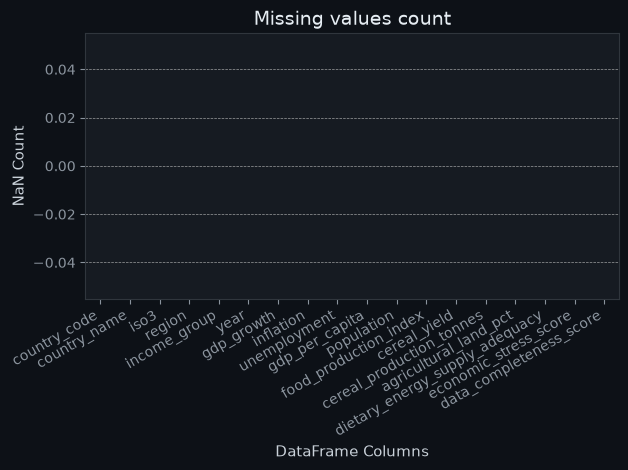

0


In [30]:
year_indicators = clip_outliers(year_indicators, target="inflation")

numeric_year_cols = year_indicators.select_dtypes(include="number").columns.drop(["year", "economic_stress_score"])

for col in numeric_year_cols:
    year_indicators = fill_missing(year_indicators, target=col, feature="year")
    year_indicators = drop_unfillable(year_indicators, target=col)
    print(f"{col}: NaN left = {year_indicators[col].isna().sum()}")
    print("")

make_fully_missing_barplot(year_indicators)
print(year_indicators.duplicated().sum())

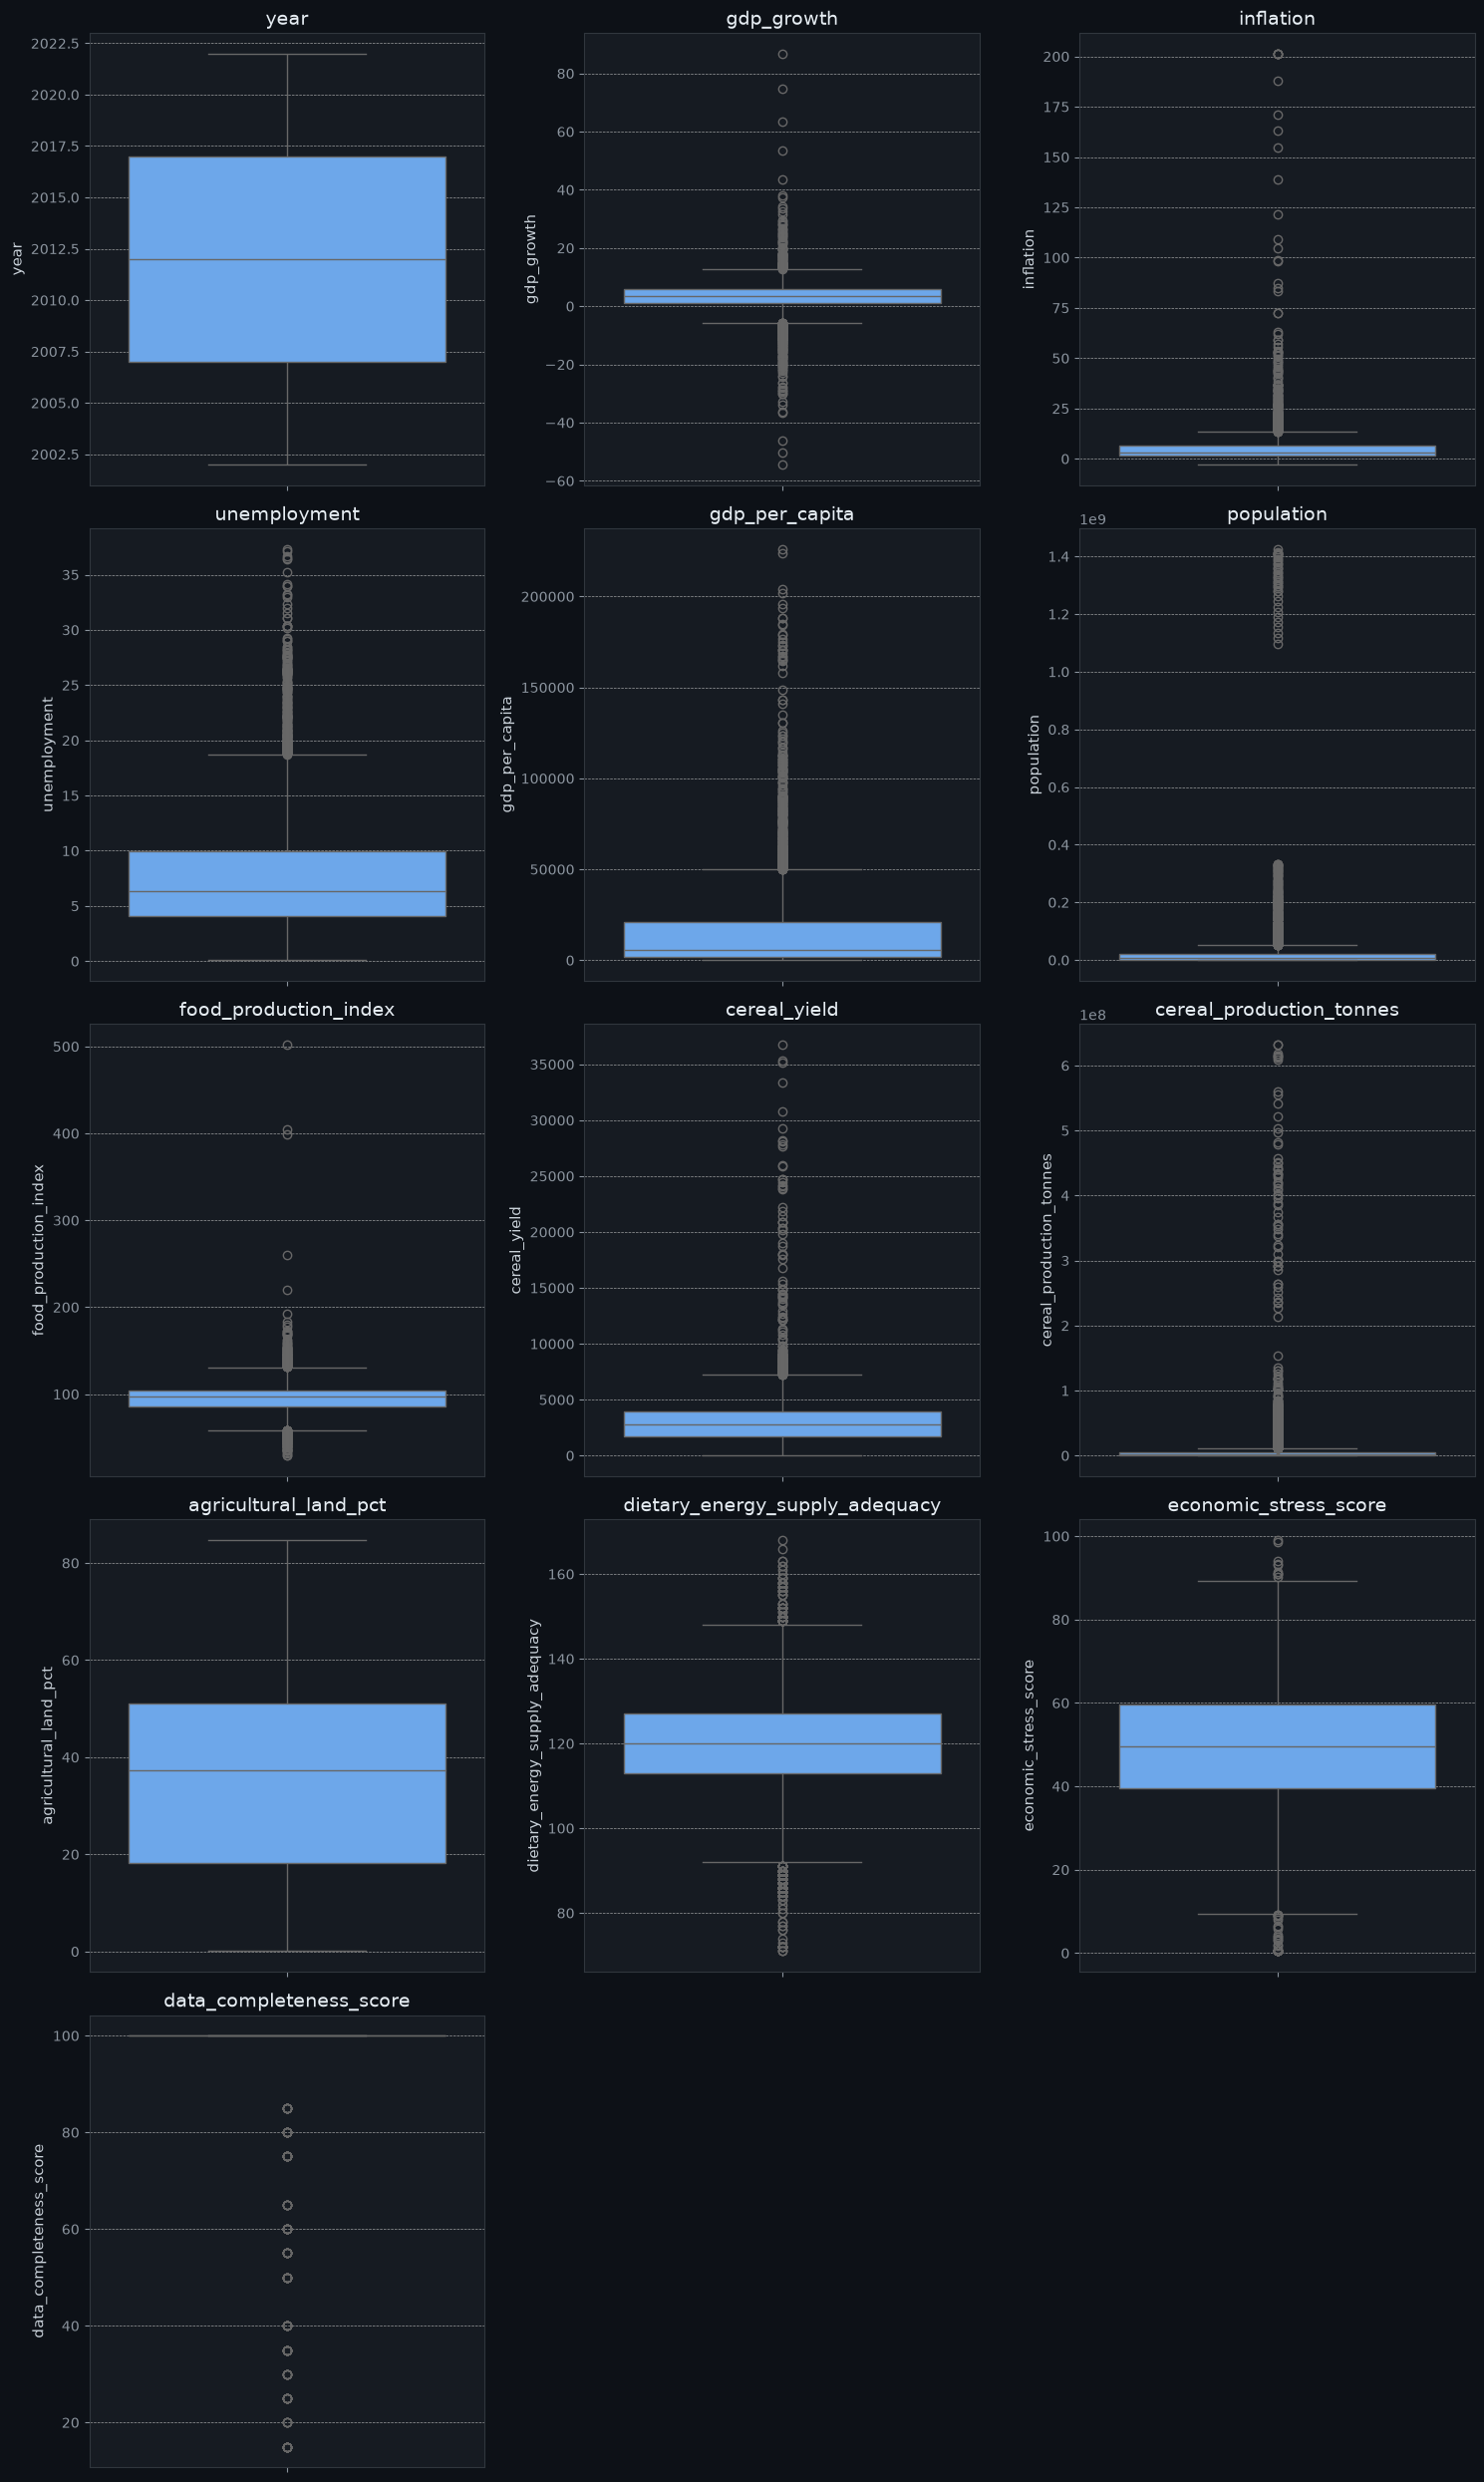

In [31]:
# ==================
# ANOMALIES YEAR INDICATORS
# ==================
make_fully_boxplot(year_indicators)

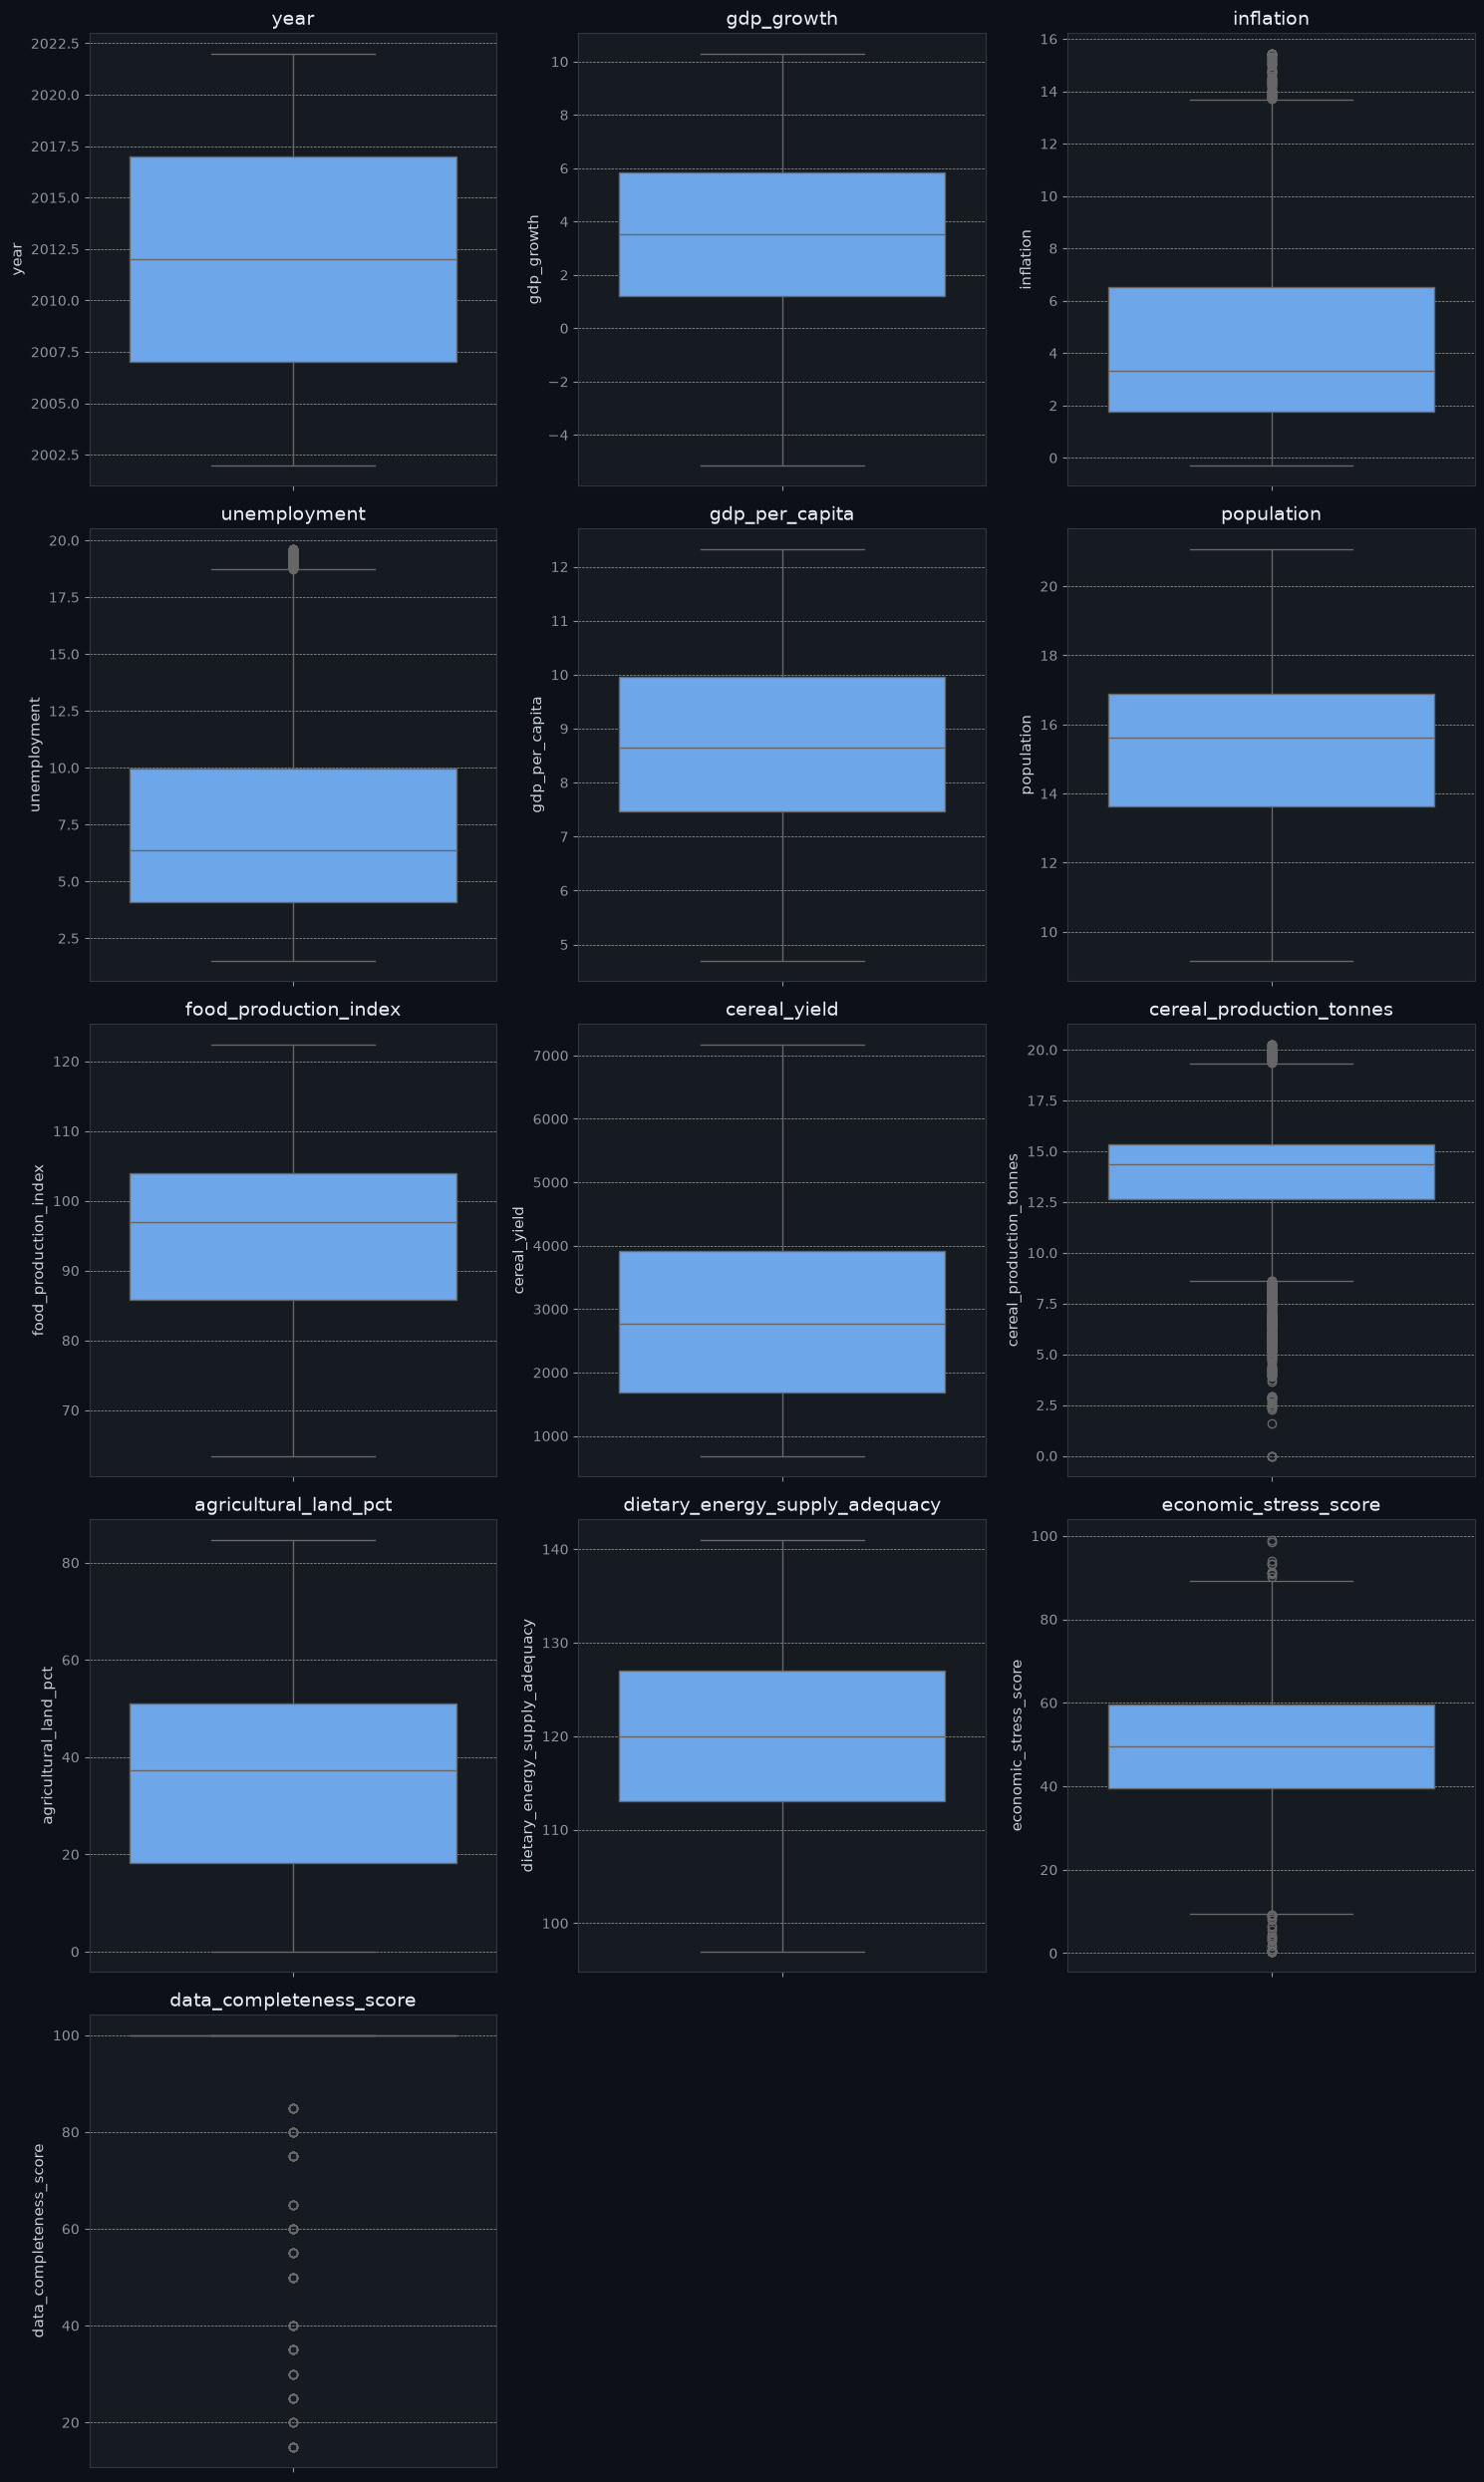

In [32]:
cols_to_clip = [
    "gdp_growth", "inflation", "unemployment",
    "cereal_yield", "dietary_energy_supply_adequacy",
    "food_production_index"
]

for col in cols_to_clip:
    year_indicators = clip_outliers(year_indicators, target=col, lower_quantile=0.05, upper_quantile=0.95)

log_cols = ["gdp_per_capita", "population", "cereal_production_tonnes"]
for col in log_cols:
    year_indicators[col] = np.log1p(year_indicators[col])

make_fully_boxplot(year_indicators)

<class 'pandas.DataFrame'>
RangeIndex: 14322 entries, 0 to 14321
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country_code                 14322 non-null  str    
 1   country_name                 14322 non-null  str    
 2   year                         14322 non-null  int64  
 3   region                       14322 non-null  str    
 4   income_group                 14322 non-null  str    
 5   inflation_score              8971 non-null   float64
 6   unemployment_score           6531 non-null   float64
 7   gdp_growth_score             11214 non-null  float64
 8   income_vulnerability_score   11569 non-null  float64
 9   food_pressure_score          11386 non-null  float64
 10  final_economic_stress_score  12762 non-null  float64
 11  stress_category              12762 non-null  str    
dtypes: float64(6), int64(1), str(5)
memory usage: 1.3 MB


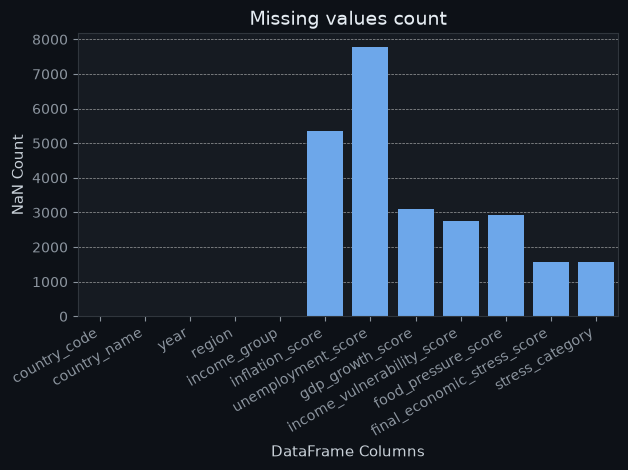

In [33]:
# ==================
# NULLS & DUPLICATES STRESS SCORE
# ==================
stress_score.info()
make_fully_missing_barplot(stress_score)

inflation_score: dropped 217 rows
inflation_score: NaN left = 0
unemployment_score: dropped 6727 rows
unemployment_score: NaN left = 0
gdp_growth_score: dropped 0 rows
gdp_growth_score: NaN left = 0
income_vulnerability_score: dropped 0 rows
income_vulnerability_score: NaN left = 0
food_pressure_score: dropped 0 rows
food_pressure_score: NaN left = 0
final_economic_stress_score: dropped 0 rows
final_economic_stress_score: NaN left = 0


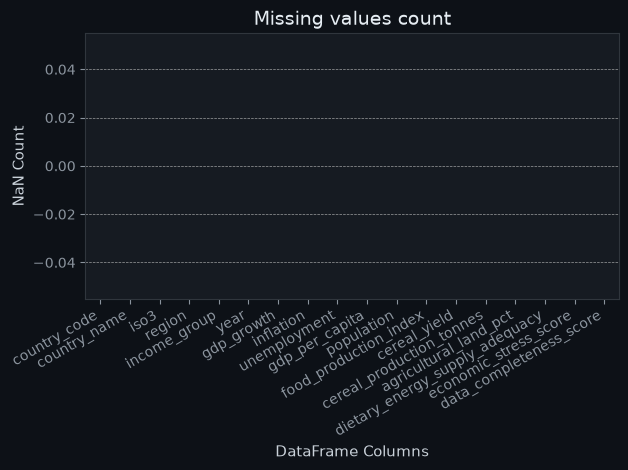

0


In [34]:
numeric_stress_cols = stress_score.select_dtypes(include="number").columns.drop("year")

for col in numeric_stress_cols:
    stress_score = fill_missing(stress_score, target=col, feature="year")
    stress_score = drop_unfillable(stress_score, target=col)
    print(f"{col}: NaN left = {stress_score[col].isna().sum()}")

make_fully_missing_barplot(year_indicators)
print(stress_score.duplicated().sum())

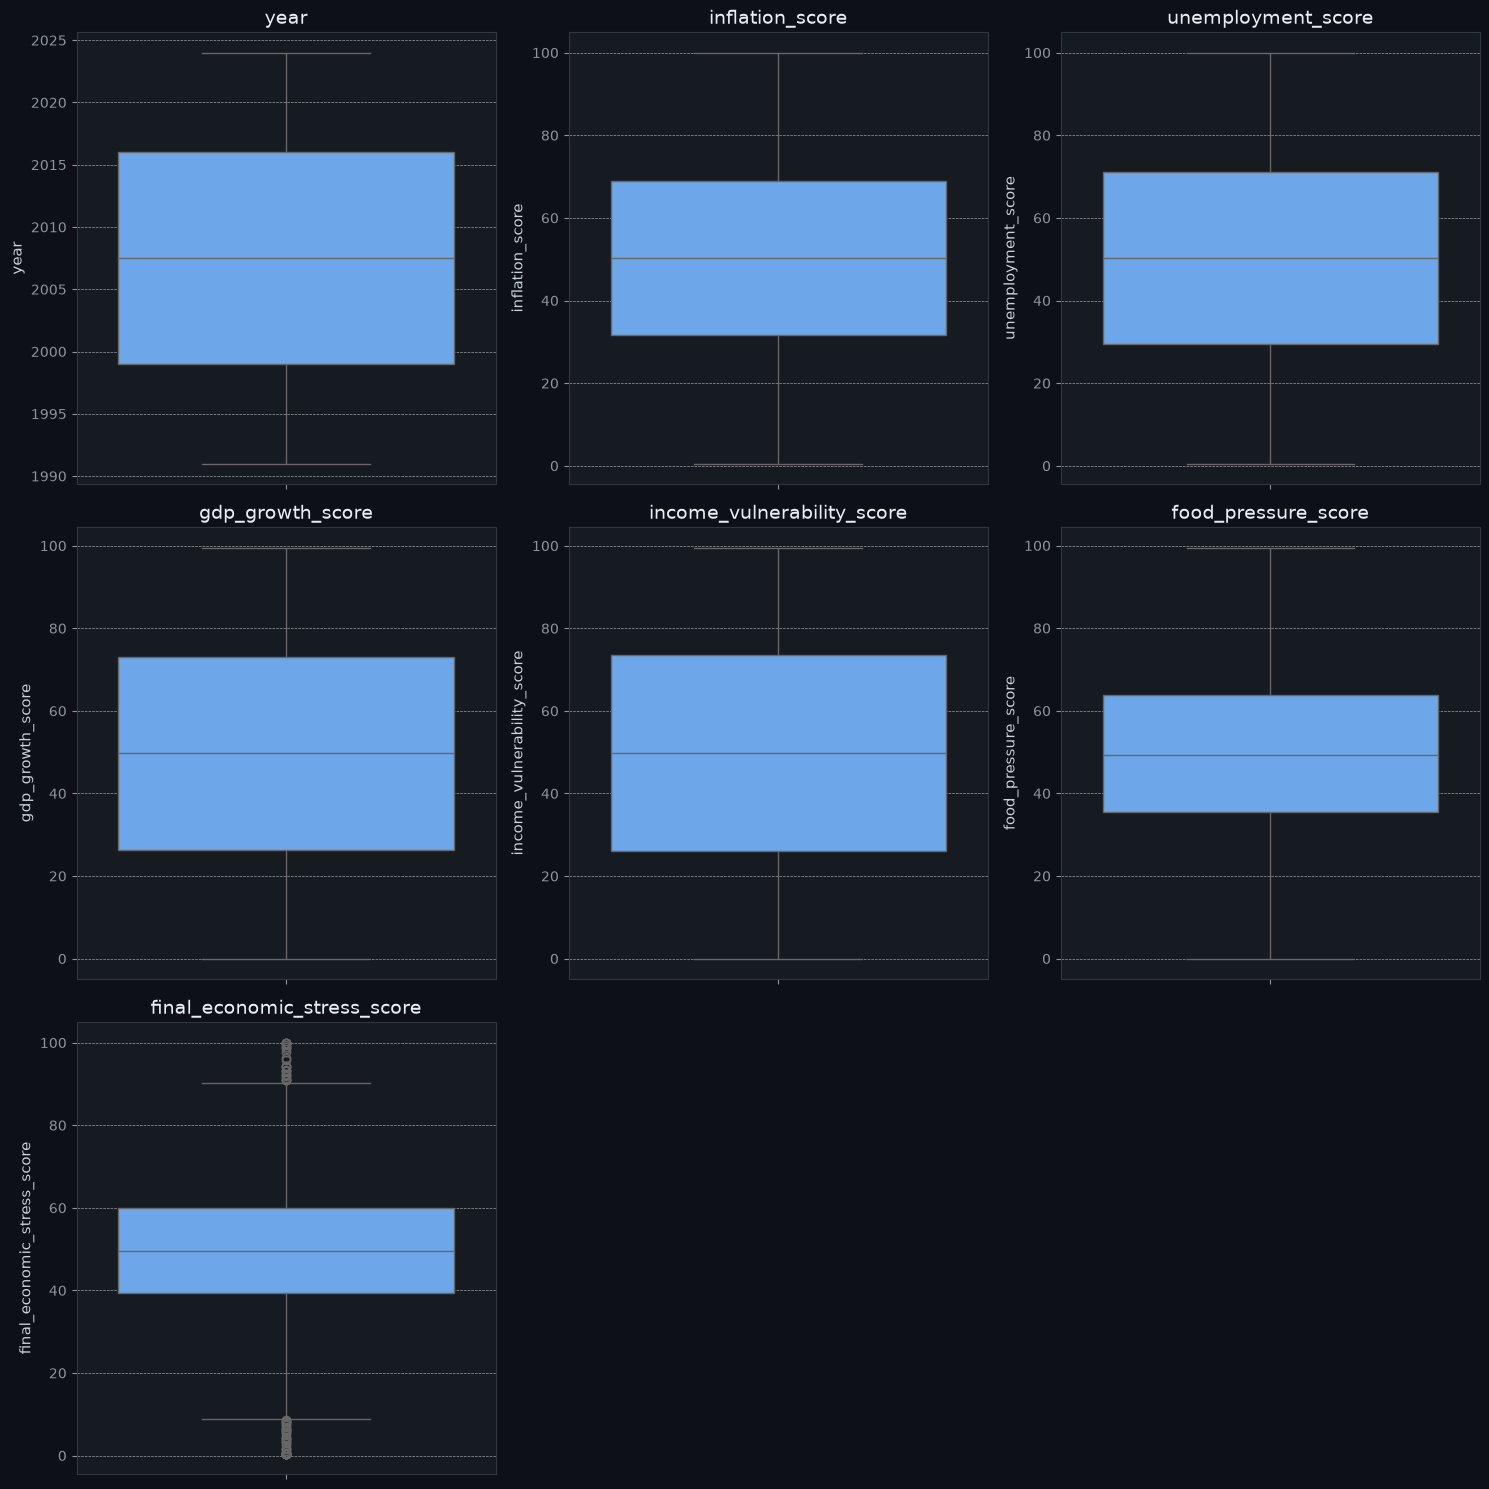

In [35]:
# ==================
# ANOMALIES STRESS SCORE
# ==================
make_fully_boxplot(stress_score)

In [36]:
# ==================
# MERGING
# ==================
merged = year_indicators.merge(
    metadata[["country_code", "latitude", "longitude"]],
    on="country_code",
    how="left"
)

print(year_indicators.shape)
print(metadata.shape)
print(merged.shape)

score_cols = [
    "country_code", "year",
    "inflation_score", "unemployment_score", "gdp_growth_score",
    "income_vulnerability_score", "food_pressure_score",
    "final_economic_stress_score"
]

merged = merged.merge(
    stress_score[score_cols],
    on=["country_code", "year"],
    how="left"
)

print(stress_score.shape)
print(merged.isna().sum())
print(merged.shape[0] == year_indicators.shape[0])
merged.head(5)

(4494, 18)
(217, 7)
(4494, 20)
(7378, 12)
country_code                      0
country_name                      0
iso3                              0
region                            0
income_group                      0
year                              0
gdp_growth                        0
inflation                         0
unemployment                      0
gdp_per_capita                    0
population                        0
food_production_index             0
cereal_yield                      0
cereal_production_tonnes          0
agricultural_land_pct             0
dietary_energy_supply_adequacy    0
economic_stress_score             0
data_completeness_score           0
latitude                          0
longitude                         0
inflation_score                   0
unemployment_score                0
gdp_growth_score                  0
income_vulnerability_score        0
food_pressure_score               0
final_economic_stress_score       0
dtype: int64
True


,country_code,country_name,iso3,region,income_group,year,gdp_growth,inflation,unemployment,gdp_per_capita,...,economic_stress_score,data_completeness_score,latitude,longitude,inflation_score,unemployment_score,gdp_growth_score,income_vulnerability_score,food_pressure_score,final_economic_stress_score
0,ABW,Aruba,ABW,Latin America & Caribbean,High income,2002,-0.944953,3.315247,6.910,9.966850,...,57.28,60.0,12.5167,-70.0167,55.882353,50.26738,90.500000,15.311005,48.752276,57.28
1,ABW,Aruba,ABW,Latin America & Caribbean,High income,2003,1.110505,3.656365,6.950,9.996545,...,53.69,60.0,12.5167,-70.0167,56.069364,50.26738,78.431373,16.746411,50.056071,53.69
2,ABW,Aruba,ABW,Latin America & Caribbean,High income,2004,7.293728,2.529129,6.800,10.073299,...,28.75,60.0,12.5167,-70.0167,39.080460,50.26738,23.039216,19.138756,49.755889,28.75
3,ABW,Aruba,ABW,Latin America & Caribbean,High income,2005,-0.383138,3.397787,7.092,10.092985,...,54.05,60.0,12.5167,-70.0167,42.372881,50.26738,94.117647,20.095694,50.530209,54.05
4,ABW,Aruba,ABW,Latin America & Caribbean,High income,2006,1.127411,3.608024,6.500,10.120479,...,53.52,60.0,12.5167,-70.0167,43.333333,50.26738,90.686275,20.952381,50.681274,53.52


In [37]:
# ==================
# SAVING DATAFRAME
# ==================
Path("../data/cleaned_data").mkdir(parents=True, exist_ok=True)
merged.to_csv("../data/cleaned_data/cleaned_merged_data.csv", index=False)